In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import DBSCAN
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

print("Dataset Loaded Successfully")
print(df.head())
print("Shape:", df.shape)

Dataset Loaded Successfully
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [3]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [4]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


In [7]:
#Risk Scoring Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model training complete")

Model training complete


In [8]:
y_pred = model.predict(X_test_scaled)

print("Prediction complete")

Prediction complete


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [10]:
risk_scores = model.predict_proba(X_test_scaled)[:, 1]

print("Risk Scores:")
print(risk_scores[:10])

Risk Scores:
[0.99 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]


In [11]:
#Anomaly Detection
dbscan = DBSCAN(
    eps=3,
    min_samples=10
)

anomaly_labels = dbscan.fit_predict(X_test_scaled)

print("Anomaly Detection Complete")
print(anomaly_labels[:20])

Anomaly Detection Complete
[-1  2  0  0  0 -1  0  0  0 -1  0  1  2  0  3 -1  0 -1  2 -1]


In [12]:
anomaly_count = np.sum(anomaly_labels == -1)

print("Total anomalies detected:", anomaly_count)

Total anomalies detected: 7446


In [13]:
#Explainability (SHAP)
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values generated")

SHAP values generated


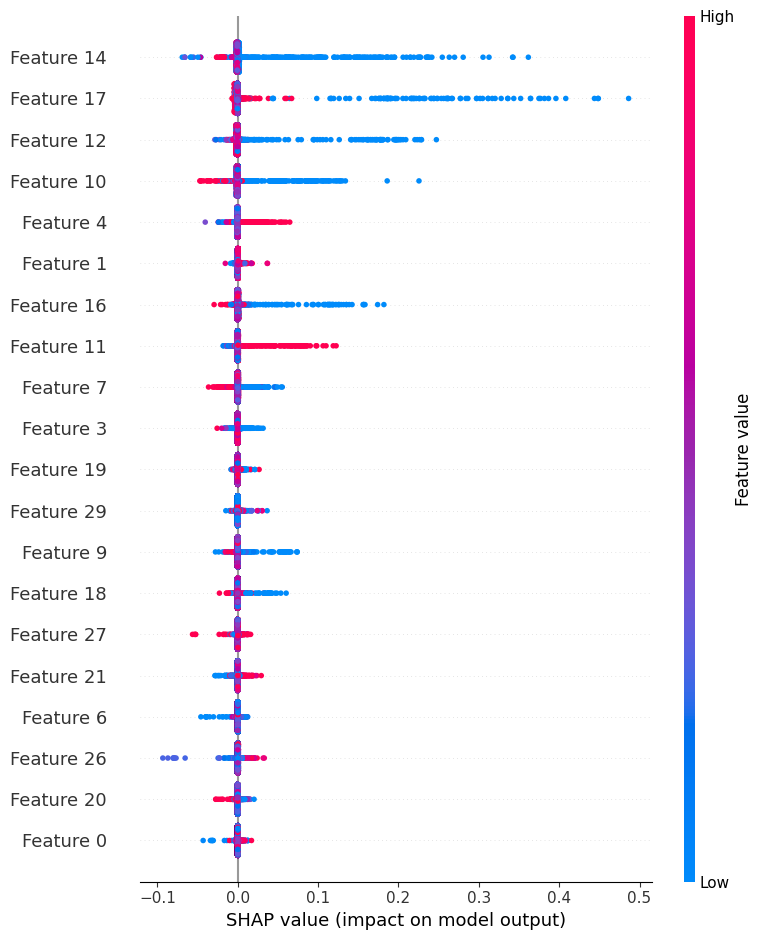

In [14]:
shap.summary_plot(shap_values[:, :, 1], X_test_scaled)

In [15]:
joblib.dump(model, "risk_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully")

Model and scaler saved successfully


In [16]:
sample_transaction = X_test.iloc[0].values.reshape(1, -1)

sample_scaled = scaler.transform(sample_transaction)

risk_score = model.predict_proba(sample_scaled)[0][1]

print("Risk Score of New Transaction:", risk_score)

Risk Score of New Transaction: 0.99


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
